In [1]:
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
from jax import random, lax
from jax.scipy.sparse.linalg import cg
from functools import partial
import numpy as np
import matplotlib.pyplot as plt

## **Data simulations**

In [2]:
# -----------------------
# Kernel construction + stats
# -----------------------
def kernel_exp(l, corr_len):
    idx = jnp.arange(l + 1, dtype=jnp.float32)
    K = jnp.where(
        corr_len == 0.0,
        jnp.eye(l + 1, dtype=jnp.float32),
        jnp.exp(-jnp.abs(idx[:, None] - idx[None, :]) / corr_len).astype(jnp.float32),
    )
    return K

def icl_kernel_stats(K):
    k = K[:-1, -1]            # (l,)
    Ksub = K[:-1, :-1]        # (l,l)
    k0 = k @ k
    k1 = k @ (Ksub @ k)
    l_ = Ksub.shape[0]
    tk  = (1.0 / l_) * jnp.trace(Ksub)
    tk2 = (1.0 / l_) * jnp.trace(Ksub @ Ksub)
    return k0, k1, tk, tk2

# -----------------------
# AR(1) sampling for exponential kernel
# -----------------------
def simulate_sufficient_stats_finite_k(key, n, d, l, rho, C, corr_len, k_tasks, old_w_set=None):
    key_wset, key_widx, key_scan = random.split(key, 3)
    L = l + 1

    dtype = C.dtype
    rho = jnp.asarray(rho, dtype=dtype)
    corr_len = jnp.asarray(corr_len, dtype=dtype)

    # Task bank
    sqrtC = jnp.linalg.cholesky(C + jnp.asarray(1e-12, dtype) * jnp.eye(d, dtype=dtype))
    if old_w_set==None:
        w_set = random.normal(key_wset, (k_tasks, d), dtype=dtype) @ sqrtC.T
    else:
        w_set = old_w_set
    w_idx = random.randint(key_widx, (n,), 0, k_tasks)
    w = w_set[w_idx]  # (n,d)

    # AR(1) params for exp kernel
    phi = jnp.where(
        corr_len == jnp.asarray(0, dtype),
        jnp.asarray(0, dtype),
        jnp.exp(-jnp.asarray(1, dtype) / corr_len),
    )
    sigma = jnp.sqrt(jnp.maximum(jnp.asarray(1, dtype) - phi * phi, jnp.asarray(0, dtype)))
    inv_sqrt_d = jnp.asarray(1, dtype) / jnp.sqrt(jnp.asarray(d, dtype))

    # t = 0 draw
    key_scan, kx0, ke0 = random.split(key_scan, 3)
    z0 = random.normal(kx0, (n, d), dtype=dtype)
    e0 = random.normal(ke0, (n,), dtype=dtype) * jnp.sqrt(rho)

    x0 = z0 * inv_sqrt_d
    y0 = jnp.sum(x0 * w, axis=1) + e0

    # initialize sums over t < l (includes t=0 if l>0)
    y_sum_x0 = y0[:, None] * x0
    y_sum_y0 = y0 * y0

    # If l==0, we should NOT include t=0 in training sums.
    y_sum_x = lax.cond(l > 0,
                       lambda _: y_sum_x0,
                       lambda _: jnp.zeros((n, d), dtype=dtype),
                       operand=None)
    y_sum_y = lax.cond(l > 0,
                       lambda _: y_sum_y0,
                       lambda _: jnp.zeros((n,), dtype=dtype),
                       operand=None)

    def step(carry, t):
        key_t, x_prev, y_sum_x, y_sum_y, y_last = carry

        key_t, kx, ke = random.split(key_t, 3)
        z_t = random.normal(kx, (n, d), dtype=dtype)
        e_t = random.normal(ke, (n,), dtype=dtype) * jnp.sqrt(rho)

        # ✅ Correct AR(1) scaling: only innovation has 1/sqrt(d)
        x_t = phi * x_prev + sigma * z_t * inv_sqrt_d
        y_t = jnp.sum(x_t * w, axis=1) + e_t

        def accum_fn(args):
            y_sum_x, y_sum_y = args
            y_sum_x = y_sum_x + y_t[:, None] * x_t
            y_sum_y = y_sum_y + y_t * y_t
            return (y_sum_x, y_sum_y)

        # accumulate for training times t < l
        y_sum_x, y_sum_y = lax.cond(t < l, accum_fn, lambda a: a, (y_sum_x, y_sum_y))

        return (key_t, x_t, y_sum_x, y_sum_y, y_t), None  # keep only last y in carry

    # scan t = 1..L-1, last step yields x_l and y_l in carry
    init = (key_scan, x0, y_sum_x, y_sum_y, y0)
    (key_end, x_last, y_sum_x, y_sum_y, y_last), _ = lax.scan(step, init, jnp.arange(1, L))

    return x_last, y_sum_x, y_sum_y, y_last, w_set

def simulate_sufficient_stats_INDEPENDENT_QUERY(key, n, d, l, rho, C, corr_len, k_tasks, old_w_set=None):
    key_wset, key_widx, key_scan, key_query = random.split(key, 4)
    L = l + 1

    dtype = C.dtype
    rho = jnp.asarray(rho, dtype=dtype)
    corr_len = jnp.asarray(corr_len, dtype=dtype)

    # Task bank
    sqrtC = jnp.linalg.cholesky(C + jnp.asarray(1e-12, dtype) * jnp.eye(d, dtype=dtype))
    if old_w_set == None:
        w_set = random.normal(key_wset, (k_tasks, d), dtype=dtype) @ sqrtC.T
    else:
        w_set = old_w_set
    w_idx = random.randint(key_widx, (n,), 0, k_tasks)
    w = w_set[w_idx]  # (n,d)

    # AR(1) params for exp kernel
    phi = jnp.where(
        corr_len == jnp.asarray(0, dtype),
        jnp.asarray(0, dtype),
        jnp.exp(-jnp.asarray(1, dtype) / corr_len),
    )
    sigma = jnp.sqrt(jnp.maximum(jnp.asarray(1, dtype) - phi * phi, jnp.asarray(0, dtype)))
    inv_sqrt_d = jnp.asarray(1, dtype) / jnp.sqrt(jnp.asarray(d, dtype))

    # t = 0 draw
    key_scan, kx0, ke0 = random.split(key_scan, 3)
    z0 = random.normal(kx0, (n, d), dtype=dtype)
    e0 = random.normal(ke0, (n,), dtype=dtype) * jnp.sqrt(rho)

    x0 = z0 * inv_sqrt_d
    y0 = jnp.sum(x0 * w, axis=1) + e0

    # initialize sums over t < l (includes t=0 if l>0)
    y_sum_x0 = y0[:, None] * x0
    y_sum_y0 = y0 * y0

    # If l==0, do NOT include t=0 in training sums
    y_sum_x = lax.cond(
        l > 0,
        lambda _: y_sum_x0,
        lambda _: jnp.zeros((n, d), dtype=dtype),
        operand=None,
    )
    y_sum_y = lax.cond(
        l > 0,
        lambda _: y_sum_y0,
        lambda _: jnp.zeros((n,), dtype=dtype),
        operand=None,
    )

    def step(carry, t):
        key_t, x_prev, y_sum_x, y_sum_y = carry

        key_t, kx, ke = random.split(key_t, 3)
        z_t = random.normal(kx, (n, d), dtype=dtype)
        e_t = random.normal(ke, (n,), dtype=dtype) * jnp.sqrt(rho)

        # Correlated AR(1) training sample
        x_t = phi * x_prev + sigma * z_t * inv_sqrt_d
        y_t = jnp.sum(x_t * w, axis=1) + e_t

        def accum_fn(args):
            y_sum_x, y_sum_y = args
            y_sum_x = y_sum_x + y_t[:, None] * x_t
            y_sum_y = y_sum_y + y_t * y_t
            return y_sum_x, y_sum_y

        # accumulate only for training times t < l
        y_sum_x, y_sum_y = lax.cond(t < l, accum_fn, lambda a: a, (y_sum_x, y_sum_y))

        return (key_t, x_t, y_sum_x, y_sum_y), None

    # Run correlated process only up to time l-1
    # For l=0 or l=1 this scan is empty, which is fine.
    init = (key_scan, x0, y_sum_x, y_sum_y)
    (_, _, y_sum_x, y_sum_y), _ = lax.scan(step, init, jnp.arange(1, l))

    # Independent query sample x_l with same marginal covariance I/d
    key_query, kx_last, ke_last = random.split(key_query, 3)
    z_last = random.normal(kx_last, (n, d), dtype=dtype)
    e_last = random.normal(ke_last, (n,), dtype=dtype) * jnp.sqrt(rho)

    x_last = z_last * inv_sqrt_d
    y_last = jnp.sum(x_last * w, axis=1) + e_last

    return x_last, y_sum_x, y_sum_y, y_last, w_set
    
# -----------------------
# Matrix-free H and H^T operators
# -----------------------
def Hv(v_mat, x_l, y_sum_x, y_sum_y, d, l):
    vA = v_mat[:, :d]     # (d,d)
    v_last = v_mat[:, d]  # (d,)

    tmp = y_sum_x @ vA.T
    term1 = (d / l) * jnp.sum(x_l * tmp, axis=1)
    term2 = (1.0 / l) * y_sum_y * (x_l @ v_last)
    return term1 + term2

def HTu(u, x_l, y_sum_x, y_sum_y, d, l):
    Xu = x_l * u[:, None]
    A = (d / l) * (Xu.T @ y_sum_x)
    b = (1.0 / l) * (x_l.T @ (u * y_sum_y))
    return jnp.concatenate([A, b[:, None]], axis=1)

# -----------------------
# ICL trace formula
# -----------------------
def ICL_trace_from_Gamma(Gamma, d, l, rho, C_test, k0, k1, tk, tk2, alpha):
    tc = (1.0 / d) * jnp.trace(C_test)
    rho1 = rho + tk * tc
    rho2 = tk * rho + tk2 * tc

    A_left = tk * C_test + (d / l) * k0 * tc * jnp.eye(d, dtype=jnp.float32)
    B_tl   = (tk * tk) * C_test + rho2 * (d / l) * jnp.eye(d, dtype=jnp.float32)
    B_br   = rho1 * rho1

    Gamma_sq = Gamma[:, :d]
    tr_gamma_sigma = (1.0 / d) * jnp.trace(Gamma_sq)
    tr_gamma_sigmaCsigma = (1.0 / d) * jnp.trace(Gamma_sq @ C_test)

    tensor_term = (1.0 / (alpha * alpha)) * (k1 * tc + k0 * rho) * (tr_gamma_sigma ** 2) \
                  + (2.0 / alpha) * k0 * tk * tr_gamma_sigma * tr_gamma_sigmaCsigma

    tr_GA = jnp.trace(Gamma_sq @ A_left.T)

    last_col = Gamma[:, d]
    tr_GBG = jnp.trace(Gamma_sq @ B_tl @ Gamma_sq.T) + B_br * (last_col @ last_col)

    return rho + tc - (2.0 / d) * tr_GA + (1.0 / d) * tr_GBG + tensor_term

def ICL_trace_from_Gamma_PROPORTIONAL(Gamma, d, l, rho, k0, k1, tk, tk2, alpha):
    k0_tilde = k0/l
    k1_tilde = k1/(l**2)
    k2_tilde = tk2/l
    
    Gamma_sq = Gamma[:, :d]

    return 1 + rho - 2*k0_tilde*jnp.trace(Gamma_sq) + k2_tilde*jnp.trace(Gamma_sq @ Gamma_sq.T) + k1_tilde*jnp.trace(Gamma_sq @ Gamma_sq) + k1_tilde*(jnp.trace(Gamma_sq)**2)

# -----------------------
# Per-sample predictor from Gamma
# -----------------------
def predict_from_Gamma(Gamma, x_l, y_sum_x, y_sum_y, d, l):
    Gamma_A = Gamma[:, :d]   # (d,d)
    Gamma_b = Gamma[:, d]    # (d,)

    # First block contribution:
    # H_i[:, :d] = (d/l) * outer(x_l[i], y_sum_x[i])
    # tr(Gamma_A @ H_i[:, :d]^T) = (d/l) * x_l[i]^T Gamma_A y_sum_x[i]
    term1 = (d / l) * jnp.sum((x_l @ Gamma_A) * y_sum_x, axis=1)

    # Last column contribution:
    # H_i[:, d] = (1/l) * y_sum_y[i] * x_l[i]
    # contribution = Gamma_b^T H_i[:, d]
    term2 = (1.0 / l) * y_sum_y * (x_l @ Gamma_b)

    return term1 + term2

# -----------------------
# Direct Monte Carlo MSE from fresh sampled data
# -----------------------
def mse_from_data(key, Gamma, n_eval, d, l, rho, C, corr_len):
    x_l, y_sum_x, y_sum_y, y_last = simulate_sufficient_stats_INDEPENDENT_QUERY(
        key,
        n=n_eval,
        d=d,
        l=l,
        rho=rho,
        C=C,
        corr_len=corr_len,
        k_tasks=n_eval,
    )
    y_hat = predict_from_Gamma(Gamma, x_l, y_sum_x, y_sum_y, d, l)
    mse = jnp.mean((y_hat - y_last) ** 2)
    return mse, y_hat, y_last

def mse_from_data_IDG(key, Gamma, n_eval, d, l, rho, C, corr_len, old_w_set):
    x_l, y_sum_x, y_sum_y, y_last, _ = simulate_sufficient_stats_finite_k(
        key,
        n=n_eval,
        d=d,
        l=l,
        rho=rho,
        C=C,
        corr_len=corr_len,
        k_tasks=n_eval,
        old_w_set = old_w_set
    )
    y_hat = predict_from_Gamma(Gamma, x_l, y_sum_x, y_sum_y, d, l)
    mse = jnp.mean((y_hat - y_last) ** 2)
    return mse, y_hat, y_last

# -----------------------
# Conjugate gradient solution for Gamma
# -----------------------
def gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg,
                      cg_tol=1e-10, cg_maxiter=5000):

    p = d * (d + 1)
    reg = (n / d) * lambdareg

    def matvec(v_flat):
        v_mat = v_flat.reshape(d, d + 1)
        hv = Hv(v_mat, x_l, y_sum_x, y_sum_y, d, l)
        ht_h_v = HTu(hv, x_l, y_sum_x, y_sum_y, d, l)
        return (reg * v_mat + ht_h_v).reshape(p)

    b_mat = HTu(y_last, x_l, y_sum_x, y_sum_y, d, l)
    b = b_mat.reshape(p)

    gamma, _ = cg(matvec, b, tol=cg_tol, maxiter=cg_maxiter)

    # report residual
    r = b - matvec(gamma)
    rel_res = jnp.linalg.norm(r) / (jnp.linalg.norm(b) + 1e-30)

    return gamma.reshape(d, d + 1), rel_res
    
# -----------------------
# One pass over Gamma error
# -----------------------
def one_replicate(key, n, d, l, rho, C, C_test, corr_len, lambdareg, alpha, k_tasks,
                  cg_tol, cg_maxiter, from_data):
    K = kernel_exp(l, corr_len)
    _, _, tk, tk2 = icl_kernel_stats(K)
    k0 = 0; k1 = 1;

    x_l, y_sum_x, y_sum_y, y_last = simulate_sufficient_stats_INDEPENDENT_QUERY(
        key, n=n, d=d, l=l, rho=rho, C=C, corr_len=corr_len, k_tasks=k_tasks
    )

    Gamma, rel_res = gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg, cg_tol, cg_maxiter)

    error_data, _, _ = mse_from_data(5*key,Gamma,n_eval=2*n,d=d,l=l,rho=rho,C=C_test,corr_len=corr_len)
    error_trace_const = ICL_trace_from_Gamma(Gamma, d, l, jnp.asarray(rho, jnp.float32), C_test, k0, k1, tk, tk2, jnp.asarray(alpha, jnp.float32))
    error_trace_prop = ICL_trace_from_Gamma_PROPORTIONAL(Gamma, d, l, jnp.asarray(rho, jnp.float32), k0, k1, tk, tk2, jnp.asarray(alpha, jnp.float32))
    
    return error_data, error_trace_const, error_trace_prop

def one_replicate_IDG(key, n, d, l, rho, C, C_test, corr_len, lambdareg, alpha, k_tasks,
                  cg_tol, cg_maxiter, from_data):
    K = kernel_exp(l, corr_len)
    _, _, tk, tk2 = icl_kernel_stats(K)
    k0 = 0; k1 = 1;

    x_l, y_sum_x, y_sum_y, y_last, w_set = simulate_sufficient_stats_finite_k(
        key, n=n, d=d, l=l, rho=rho, C=C, corr_len=corr_len, k_tasks=k_tasks
    )

    Gamma, rel_res = gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg, cg_tol, cg_maxiter)

    error_data, _, _ = mse_from_data_IDG(5*key, Gamma, n_eval=2*n,d=d,l=l,rho=rho,C=C_test,corr_len=corr_len, old_w_set=w_set)

    return error_data, 0, 0
# -----------------------
# Multiple passes to average over Gamma error
# -----------------------
@partial(jax.jit, static_argnames=("numavg", "n", "d", "l", "k_tasks", "cg_maxiter"))
def avg_over_replicates(
    base_key, numavg, n, d, l, rho, C, C_test, corr_len,
    lambdareg, alpha, k_tasks, from_data, cg_tol=1e-4, cg_maxiter=200
):
    keys = random.split(base_key, numavg)

    dtype = C.dtype
    init = (
        jnp.asarray(0, dtype=jnp.int32),         # count
        jnp.zeros((3,), dtype=dtype),            # mean: [mean_x, mean_y]
        jnp.zeros((3,), dtype=dtype),            # M2:   [M2_x, M2_y]
    )

    def body(state, k):
        count, mean, M2 = state

        x, y, z = one_replicate_IDG(
            k, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alpha, k_tasks, cg_tol, cg_maxiter, from_data
        )

        vals = jnp.stack([x, y, z])   # shape (2,)

        count_new = count + 1
        delta = vals - mean
        mean_new = mean + delta / count_new
        delta2 = vals - mean_new
        M2_new = M2 + delta * delta2

        return (count_new, mean_new, M2_new), vals

    (count, mean, M2), errs = lax.scan(body, init, keys)

    # sample std (ddof=1)
    var = jnp.where(
        count > 1,
        M2 / (count - 1),
        jnp.zeros((3,), dtype=dtype)
    )
    std = jnp.sqrt(var)

    return mean, std, errs

# -----------------------
# Sweeping functions 
# -----------------------
def run_sweep_over_corr_lens(lens, seed=0, d=32, tau=0.5, alpha=1.0, kappa=1.0,
              rho=0.01, numavg=20, lambdareg=1e-6,
              cg_tol=1e-4, cg_maxiter=200, from_data=False):
    l = int(alpha * d)
    n = int(tau * d * d)
    k_tasks = int(kappa * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for corr_len in list(lens):
        key, subkey = random.split(key)
        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alpha, k_tasks, from_data, cg_tol, cg_maxiter)
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)

def run_sweep_over_taus(taus, seed=0, d=32, alpha=1.0, kappa=1.0,
              rho=0.01, corr_len=0.0, numavg=20, lambdareg=1e-6,
              cg_tol=1e-4, cg_maxiter=200, from_data=False):
    l = int(alpha * d)
    k_tasks = int(kappa * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for tau in list(taus):
        key, subkey = random.split(key)
        n = int(tau * d * d)
        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alpha, k_tasks, from_data, cg_tol, cg_maxiter
        )
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)

def run_sweep_over_alphas(alphas, lens, seed=0, d=32, tau=0.5, kappa=1.0,
              rho=0.01, numavg=20, lambdareg=1e-6,
              cg_tol=1e-4, cg_maxiter=200, from_data=False):
    n = int(tau * d * d)
    k_tasks = int(kappa * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for i in range(len(alphas)):
        
        key, subkey = random.split(key)
        l = int(alphas[i] * d)
        corr_len = lens[i]

        print(f"tau is {tau}")
        print(f"kappa is {kappa}")
        print(f"beta is {corr_len/l}")
        print(f"alpha is {alphas[i]}")

        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alphas[i], k_tasks, from_data, cg_tol, cg_maxiter
        )
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)

def run_sweep_over_kappas(kappas, seed=0, d=32, tau=0.5, alpha=1.0,
              rho=0.01, corr_len=0.0, numavg=20, lambdareg=1e-6,
              cg_tol=1e-4, cg_maxiter=200, from_data=False):
    l = int(alpha * d)
    n = int(tau * d * d)

    C = jnp.eye(d, dtype=jnp.float64)
    C_test = C
    
    key = random.PRNGKey(seed)
    samples = []
    stds = []

    for kappa in list(kappas):
        key, subkey = random.split(key)
        k_tasks = int(kappa * d)
        val_mean, val_std, _ = avg_over_replicates(
            subkey, numavg, n, d, l, rho, C, C_test, corr_len,
            lambdareg, alpha, k_tasks, from_data, cg_tol, cg_maxiter
        )
        samples.append(val_mean)
        stds.append(val_std)

    return jnp.stack(samples), jnp.stack(stds)

## **Kernel Visualisation**

In [3]:
l = 128

K0 = np.linalg.eigvals(kernel_exp(l, 0))
K1 = np.linalg.eigvals(kernel_exp(l, 10))
K2 = np.linalg.eigvals(kernel_exp(l, 128))
K3 = np.linalg.eigvals(kernel_exp(l, 12800))

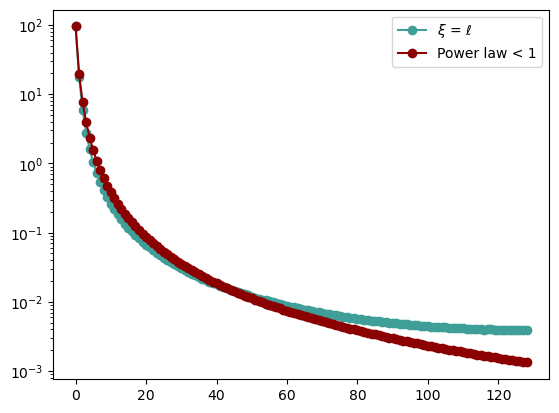

In [30]:
colors = [
    #"#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
]
# plt.plot(range(l+1), K0, marker='o', color=colors[0], label=r'$\xi$ = 0')
# plt.plot(range(l+1), K1, marker='o', color=colors[1], label=r'$\xi$ = 10')
plt.plot(range(l+1), K2, marker='o', color=colors[2], label=r'$\xi$ = $\ell$')
# plt.plot(range(l+1), K3, marker='o', color=colors[3], label=r'$\xi$ = $10\ell$')
plt.plot(range(l+1), [((i+1)**(-2.3))*np.max(K2) for i in range(l+1)], marker='o', color='darkred', label=r'Power law < 1')
# plt.plot(range(l+1), [((i+1)**(-1.3))*np.max(K1) for i in range(l+1)], marker='o', color='orange', label=r'Power law > 1')

plt.legend()
plt.yscale('log')

Text(0.5, 1.0, 'Corr len = 100 context len')

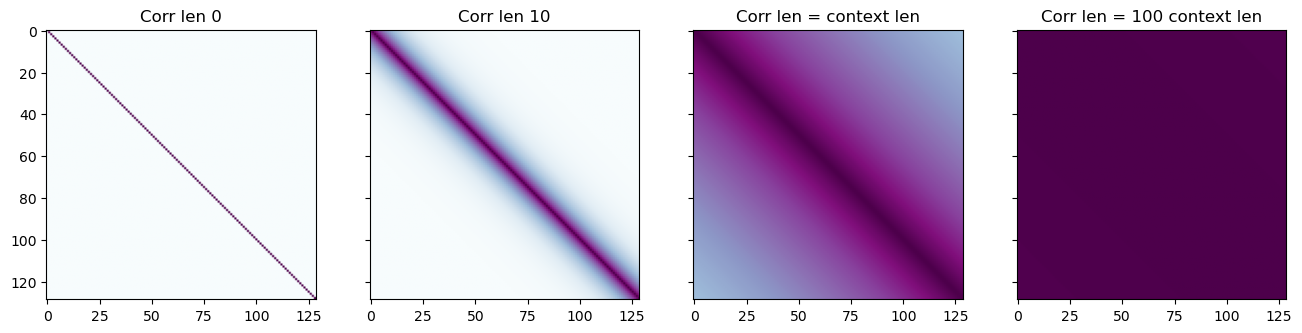

In [80]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

axes[0].imshow(K0, cmap='BuPu', vmin=0, vmax=1)
axes[0].set_title('Corr len 0')
axes[1].imshow(K1, cmap='BuPu', vmin=0, vmax=1)
axes[1].set_title('Corr len 10')
axes[2].imshow(K2, cmap='BuPu', vmin=0, vmax=1)
axes[2].set_title('Corr len = context len')
axes[3].imshow(K3, cmap='BuPu', vmin=0, vmax=1)
axes[3].set_title('Corr len = 100 context len')

## **Transition between Constant and Proportional**

In [9]:
tau = 4.0
alpha = 1.0
kappa = 0.5
rho = 0.01
numavg = 20
lambdareg = 1e-8

deez = [16, 32]

means = {}
sts = {}
lens = {}

for d in deez:
    l = int(alpha*d)
    mults = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 4.0, 8.0, 10.0, 20.0, 50.0, 100.0]
    mylen = [0, 1, 2, 4, 6, 8, 10] + [l*mult for mult in mults]
    lens[d] = np.sort(np.array(mylen))
    means[d], sts[d], = run_sweep_over_corr_lens(lens[d], seed=0, d=d, tau=tau, alpha=alpha, kappa=kappa,
                rho=rho, numavg=numavg, lambdareg=lambdareg,
                cg_tol=1e-8, cg_maxiter=2000) 
    print(f"{d} is done")

16 is done
32 is done


Text(0, 0.5, 'ICL Error')

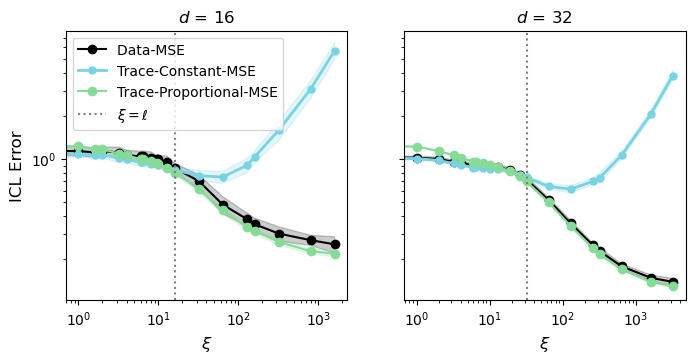

In [11]:
length=4*len(deez)
fig, axes = plt.subplots(1, len(deez), figsize=(length, 3.5), sharey=True)

colors = [
    "black",  # rich blue (added)
    "#78D3E3",  # teal
    "#86DB99",  # soft green
]

for i, d in enumerate(deez):
    axes[i].plot(lens[d], means[d][:,0], marker='o', label='Data-MSE ', color=colors[0])#, lw=3, ms=9) 
    axes[i].fill_between(lens[d], np.array(means[d][:,0])-np.array(sts[d][:,0]), np.array(means[d][:,0])+np.array(sts[d][:,0]), alpha=0.2, color=colors[0])
    axes[i].plot(lens[d], means[d][:,1], marker='o', label='Trace-Constant-MSE', color=colors[1], lw=2, ms=5) 
    axes[i].fill_between(lens[d], np.array(means[d][:,1])-np.array(sts[d][:,1]), np.array(means[d][:,1])+np.array(sts[d][:,1]), alpha=0.2, color=colors[1]) 
    axes[i].plot(lens[d], means[d][:,2], marker='o', label='Trace-Proportional-MSE', color=colors[2])#, lw=2, ms=5) 
    axes[i].fill_between(lens[d], np.array(means[d][:,2])-np.array(sts[d][:,2]), np.array(means[d][:,2])+np.array(sts[d][:,2]), alpha=0.2, color=colors[2]) 
    
    axes[i].set_xscale('log')
    axes[i].set_yscale('log')
    axes[i].set_title(rf'$d$ = {d}', fontsize=12) #, $\alpha$ = {alpha}, $\tau$ = {tau}, $\kappa$ = {kappa}')
    axes[i].set_xlabel(r'$\xi$', fontsize=12)
    
    axes[i].axvline(int(alpha*d), linestyle=':', color='gray', label=r'$\xi = \ell$')

axes[0].legend()
axes[0].set_ylabel('ICL Error', fontsize=12)

# plt.savefig(f'beta_tau{tau}_alpha{alpha}_kappa{kappa}.pdf',bbox_inches='tight')

In [28]:
taus

array([0.1, 0.3, 0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9, 2.1])

In [33]:
taus = np.linspace(0.1, 2.1, 11)
means, sts = run_sweep_over_taus(taus, seed=0, d=128, alpha=1.0, kappa=1.0,
              rho=0.01, corr_len=6400, numavg=20, lambdareg=1e-8,
              cg_tol=1e-8, cg_maxiter=200)

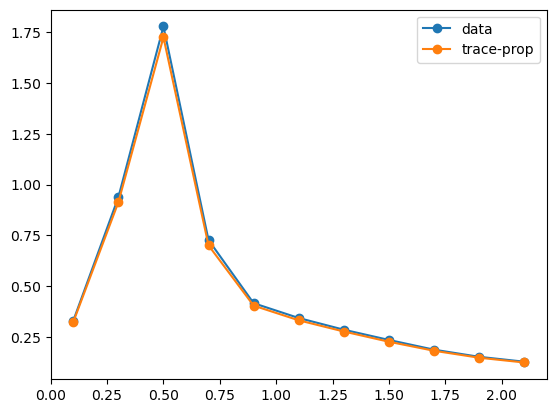

In [32]:
plt.plot(taus, means[:,0], marker='o', label='data')
plt.plot(taus, means[:,2], marker='o', label='trace-prop')
# plt.plot(taus, [icl_uncorrelated(tau, 1, 1, 0.5, 0.01, 1, 1) for tau in taus])
plt.legend()

In [57]:
icl_uncorrelated(tau, alpha, alpha, kappa, rho, 1, 1)

np.float64(0.8326252834087329)

In [58]:
means[128][0,0]

Array(0.84625422, dtype=float64)

## **Formulas**

In [3]:
# -----------------------
# Stieltjes transforms
# -----------------------
def M_kappa(nu, kappa, c):
    # Ctr = c*I
    return 2 / ( (nu + c - c/kappa) + np.sqrt((nu + c - c/kappa)**2 + 4*c*nu/kappa) )
def M_kappa_prime(nu, kappa, c):
    M = M_kappa(nu, kappa, c)
    return (-1/2) * M**2 * (1 + (nu + c + c/kappa)/np.sqrt((nu + c - c/kappa)**2 + 4*c*nu/kappa))

# -----------------------
# Current error formula 
# -----------------------
def icl_correlated(tau, alpha, kappa, rho, K):
    # --- necessary constants ---
    k = K[:-1, -1]; K_sub = K[:-1,:-1]
    k0 = k@k
    k1 = k@K_sub@k
    ell = K_sub.shape[0]
    rho1 = 1.0 + rho
    rho2 = (1/ell)*np.trace(K_sub@K_sub) + rho
    phi1 = (k1 + rho * k0) / (alpha**2)
    phi2 = k0 / alpha                    
    psi1, psi2 = phi1, phi2

    # --- effective ridges ---
    if tau >= 1:
        tilde_lambda = 0
    else:
        tilde_lambda = ((1-tau)/tau)/M_kappa(rho2/alpha, kappa/tau, 1)
    sigma = tilde_lambda + rho2/alpha
    tilde_sigma = sigma - k0 / alpha

    # --- stieltjes transforms ---
    calM = M_kappa(sigma, kappa, 1)
    calM_prime = M_kappa_prime(sigma, kappa, 1)

    # --- c ---
    denom_c = 1.0 - 2.0 * tilde_lambda * calM - (tilde_lambda**2) * calM_prime - tau
    c = (1.0 + rho2 / alpha) * (calM + tilde_lambda * calM_prime) / denom_c

    # --- vectors m1, m2, m3 (shape (2,)) ---
    m1 = np.array([
        calM,
        phi2 * (1.0 - sigma * calM),
    ], dtype=float)

    m2 = np.array([
        1.0 - tilde_sigma * calM,
        phi2 * (1.0 - tilde_sigma + sigma * tilde_sigma * calM),
    ], dtype=float)

    m3 = np.array([
        calM + tilde_sigma * calM_prime,
        phi2 * (1.0 - sigma * calM - tilde_sigma * calM - sigma * tilde_sigma * calM_prime),
    ], dtype=float)

    # --- 2x2 matrices ---
    MatM = np.array([
        [-calM_prime,                 phi2 * (calM + sigma * calM_prime)],
        [ phi2 * (calM + sigma * calM_prime),  (phi2**2) * (1.0 - 2.0 * sigma * calM - (sigma**2) * calM_prime)],
    ], dtype=float)
    S_inv = np.array([
        [calM,                         1.0 + phi2 * (1.0 - sigma * calM)],
        [1.0 + phi2 * (1.0 - sigma * calM),   -phi1 + (phi2**2) * (1.0 - sigma + (sigma**2) * calM)],
    ], dtype=float)
    S = np.linalg.inv(S_inv)

    # helper quadratic forms
    def qform(v, A, w):
        return float(v.T @ A @ w)

    # --- formula ---
    term1 = (1.0 - c) * rho1
    term2 = -2.0 * (1.0 + psi2) * (1.0 - tilde_sigma * calM - qform(m1, S, m2))
    term3 = (psi1 + 2.0 * psi2) * (1.0 - tilde_sigma * calM - qform(m1, S, m2))**2
    term4_pref = (1.0 + rho2 / alpha + c * tilde_lambda)
    term4_inside = (
        1.0
        - 2.0 * tilde_sigma * calM
        - (tilde_sigma**2) * calM_prime
        - 2.0 * qform(m2, S, m3)
        + float(m2.T @ S.T @ MatM @ S @ m2)
    )
    term4 = term4_pref * term4_inside
    term5 = c * (1.0 + sigma - 2.0 * tilde_sigma + (tilde_sigma**2) * calM - qform(m2, S, m2))
    e_icl = term1 + term2 + term3 + term4 + term5
    return float(e_icl)
    #return float(term3 + term4 + term5 - c*rho1)
    #return float(-term2)

def idg_guess(tau, alpha, kappa, rho, K):
    # --- necessary constants ---
    k = K[:-1, -1]; K_sub = K[:-1,:-1]
    k0 = k@k
    k1 = k@K_sub@k
    ell = K_sub.shape[0]
    rho1 = 1.0 + rho
    rho2 = (1/ell)*np.trace(K_sub@K_sub) + rho
    phi1 = (k1 + rho * k0) / (alpha**2)
    phi2 = k0 / alpha                    
    psi1, psi2 = phi1, phi2
    
    # --- effective ridges ---
    if tau >= 1:
        tilde_lambda = 0
    else:
        tilde_lambda = ((1-tau)/tau)/M_kappa(rho2/alpha, kappa/tau, 1)
    sigma = tilde_lambda + rho2/alpha
    tilde_sigma = sigma - k0 / alpha

    # --- stieltjes transforms ---
    calM = M_kappa(sigma, kappa, 1)
    calM_prime = M_kappa_prime(sigma, kappa, 1)

    # --- vectors m1, m2, m3 (shape (2,)) ---
    m1 = np.array([
        calM,
        phi2 * (1.0 - sigma * calM),
    ], dtype=float)

    m2 = np.array([
        1.0 - tilde_sigma * calM,
        phi2 * (1.0 - tilde_sigma + sigma * tilde_sigma * calM),
    ], dtype=float)

    m3 = np.array([
        calM + tilde_sigma * calM_prime,
        phi2 * (1.0 - sigma * calM - tilde_sigma * calM - sigma * tilde_sigma * calM_prime),
    ], dtype=float)

    # --- 2x2 matrices ---
    MatM = np.array([
        [-calM_prime,                 phi2 * (calM + sigma * calM_prime)],
        [ phi2 * (calM + sigma * calM_prime),  (phi2**2) * (1.0 - 2.0 * sigma * calM - (sigma**2) * calM_prime)],
    ], dtype=float)
    S_inv = np.array([
        [calM,                         1.0 + phi2 * (1.0 - sigma * calM)],
        [1.0 + phi2 * (1.0 - sigma * calM),   -phi1 + (phi2**2) * (1.0 - sigma + (sigma**2) * calM)],
    ], dtype=float)
    S = np.linalg.inv(S_inv)

    # helper quadratic forms
    def qform(v, A, w):
        return float(v.T @ A @ w)

    # --- q ---
    denom_q = tau - (1.0 - 2.0 * tilde_lambda * calM - (tilde_lambda**2) * calM_prime)
    old_q = (rho + sigma - (sigma**2) * calM - tilde_lambda * (1 - 2*sigma*calM - (sigma**2)*calM_prime)) / denom_q 

    new_q = (qform(m2, S, m2) - tilde_lambda * (- 2.0 * qform(m2, S, m3) + float(m2.T @ S.T @ MatM @ S @ m2)) 
            - 2*phi2*(tilde_lambda*(calM + sigma*calM_prime) + 1 - sigma*calM)
            - (phi2**2)*(calM - tilde_lambda*calM_prime))
    new_q = new_q/denom_q

    return new_q + old_q
    
def icl_correlated_REARRANGED(tau, alpha, kappa, rho, K):
    # --- necessary constants ---
    k = K[:-1, -1]; K_sub = K[:-1,:-1]
    k0 = k@k
    k1 = k@K_sub@k
    ell = K_sub.shape[0]
    rho1 = 1.0 + rho
    rho2 = (1/ell)*np.trace(K_sub@K_sub) + rho
    phi1 = (k1 + rho * k0) / (alpha**2)
    phi2 = k0 / alpha                    
    psi1, psi2 = phi1, phi2

    # --- effective ridges ---
    if tau >= 1:
        tilde_lambda = 0
    else:
        tilde_lambda = ((1-tau)/tau)/M_kappa(rho2/alpha, kappa/tau, 1)
    sigma = tilde_lambda + rho2/alpha
    tilde_sigma = sigma - k0 / alpha

    # --- stieltjes transforms ---
    calM = M_kappa(sigma, kappa, 1)
    calM_prime = M_kappa_prime(sigma, kappa, 1)

    # --- vectors m1, m2, m3 (shape (2,)) ---
    m1 = np.array([
        calM,
        phi2 * (1.0 - sigma * calM),
    ], dtype=float)

    m2 = np.array([
        1.0 - tilde_sigma * calM,
        phi2 * (1.0 - tilde_sigma + sigma * tilde_sigma * calM),
    ], dtype=float)

    m3 = np.array([
        calM + tilde_sigma * calM_prime,
        phi2 * (1.0 - sigma * calM - tilde_sigma * calM - sigma * tilde_sigma * calM_prime),
    ], dtype=float)

    # --- 2x2 matrices ---
    MatM = np.array([
        [-calM_prime,                 phi2 * (calM + sigma * calM_prime)],
        [ phi2 * (calM + sigma * calM_prime),  (phi2**2) * (1.0 - 2.0 * sigma * calM - (sigma**2) * calM_prime)],
    ], dtype=float)
    S_inv = np.array([
        [calM,                         1.0 + phi2 * (1.0 - sigma * calM)],
        [1.0 + phi2 * (1.0 - sigma * calM),   -phi1 + (phi2**2) * (1.0 - sigma + (sigma**2) * calM)],
    ], dtype=float)
    S = np.linalg.inv(S_inv)

    # helper quadratic forms
    def qform(v, A, w):
        return float(v.T @ A @ w)

    # --- q ---
    denom_q = tau - (1.0 - 2.0 * tilde_lambda * calM - (tilde_lambda**2) * calM_prime)
    old_q = (rho + sigma - (sigma**2) * calM - tilde_lambda * (1 - 2*sigma*calM - (sigma**2)*calM_prime)) / denom_q 

    new_q = (qform(m2, S, m2) - tilde_lambda * (- 2.0 * qform(m2, S, m3) + float(m2.T @ S.T @ MatM @ S @ m2)) 
            - 2*phi2*(tilde_lambda*(calM + sigma*calM_prime) + 1 - sigma*calM)
            - (phi2**2)*(calM - tilde_lambda*calM_prime))
    new_q = new_q/denom_q

    # --- independent part ---
    e_ICL_independent_query = (rho
        + (rho2 / alpha)
        * (
            1
            + (old_q - 2 * sigma) * calM
            + (old_q * tilde_lambda - sigma**2) * calM_prime
        )
        + old_q * calM + (old_q * tilde_lambda - sigma**2) * calM_prime
    )

    tail = (
        - 2 * psi2
        + 2 * psi2 * (tilde_sigma + rho2 / alpha) * calM
        + (1 + rho2 / alpha) * (
            new_q * (calM + tilde_lambda * calM_prime)
            + psi2 * (2 * sigma - psi2) * calM_prime
            + float(m2.T @ S.T @ MatM @ S @ m2)
            - 2 * qform(m2, S, m3)
        )
        + 2 * (1 + psi2) * qform(m1, S, m2)
        + (psi1 + 2 * psi2) * (1 - tilde_sigma * calM - qform(m1, S, m2)) ** 2
    )

    return e_ICL_independent_query, tail
    
# -----------------------
# Original error formula 
# -----------------------
def icl_uncorrelated(tau, alpha_tr, alpha_test, kappa, rho, ctr, ctest):
    if tau == 1:
        return None
    if tau > 1:
        xi = 0
        nu = (rho + ctr)/alpha_tr
    if tau < 1:
        xi = ((1-tau)/tau)/M_kappa((rho + ctr)/alpha_tr, kappa/tau, ctr)
        nu = (rho + ctr)/alpha_tr + xi

    M = M_kappa(nu, kappa, ctr)
    Mprime = M_kappa_prime(nu,kappa,ctr)
    zero = ctest + rho
    linear = ctest*(1 - nu*M)
    quadratic_eq = ((ctest+rho)/alpha_test + ctest)*(1 - 2*nu*M - (nu**2)*Mprime)
    c_e = ((rho + ctr) - (ctr-nu+(nu**2)*M) - xi*(1 - 2*nu*M - (nu**2)*Mprime))/(1 - 2*xi*M - (xi**2)*Mprime - tau)
    quadratic_extra = -c_e * ((ctest+rho)/alpha_test + ctest) * (M + xi*Mprime)
    return zero -2*linear + quadratic_eq + quadratic_extra

# -----------------------
# Sweeping functions 
# -----------------------
def theory_sweep_over_corr_lens(lens, d=32, tau=0.5, alpha=1.0, kappa=1.0, rho=0.01):
    l = int(d*alpha)

    theory = []
    for corr_len in lens:
        K = kernel_exp(l, corr_len)
        theory.append(icl_correlated(tau,alpha,kappa,rho,K))
    return theory

def theory_sweep_over_taus(taus, d=32, alpha=1.0, kappa=1.0, rho=0.01, corr_len=0.0):
    l = int(d*alpha)
    K = kernel_exp(l, corr_len)
    
    theory = []
    for tau in taus:
        theory.append(icl_correlated(tau,alpha,kappa,rho,K))
    return theory

def theory_sweep_over_alphas(alphas, lens, d=32, tau=0.5, kappa=1.0, rho=0.01):
    theory = []
    for i in range(len(alphas)):
        l = int(d*alphas[i])
        K = kernel_exp(l, lens[i])
        theory.append(icl_correlated(tau,alphas[i],kappa,rho,K))
    return theory

def theory_sweep_over_kappas(kappas, d=32, tau=0.5, alpha=1.0, rho=0.01, corr_len=0.0):
    l = int(d*alpha)
    K = kernel_exp(l, corr_len)
    
    theory = []
    for kappa in kappas:
        theory.append(icl_correlated(tau,alpha,kappa,rho,K))
    return theory



In [8]:
kappa = 1
tau = 0.5
alpha = 2
d = 128
rho = 0.01
numavg = 20
lambdareg = 1e-8

lens = np.linspace(0, 4*alpha, 21)

runs_mean, runs_stds, =  run_sweep_over_corr_lens(lens, seed=0, d=d, tau=tau, alpha=alpha, kappa=kappa,
            rho=rho, numavg=numavg, lambdareg=lambdareg,
            cg_tol=1e-8, cg_maxiter=2000, from_data=True)

theory = []
for xi in lens:
    l = int(alpha * d)
    K = kernel_exp(l, xi)
    theory.append(tau*idg_guess(tau, alpha, kappa, rho, K))

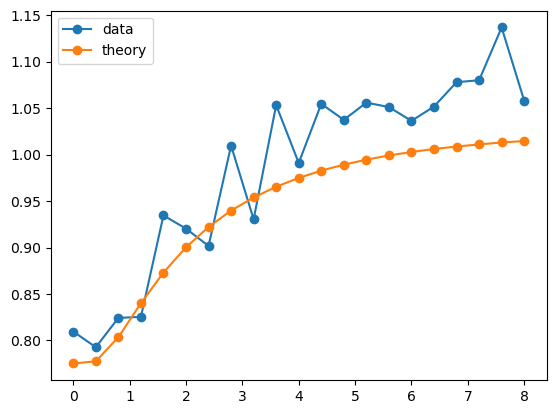

In [9]:
plt.plot(lens, runs_mean[:,0], marker='o', label='data')
plt.plot(lens, np.array(theory), marker='o', label='theory')
plt.legend()

In [10]:
d = 128
kappas = np.logspace(np.log10(0.1), np.log10(1000), 21)
alphas = [1.0, 10.0, 100.0]
tau_mult = 5
rho = 0.01

for alpha in (alphas):
    xi = alpha
    tau = tau_mult*alpha
    l = int(alpha * d)
    K = kernel_exp(l, xi)
    vals[alpha] = [idg_guess(tau, alpha, kappa, rho, K) for kappa in kappas]

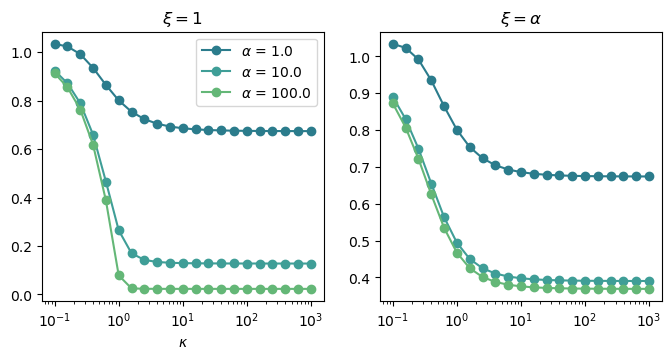

In [14]:
colors = [
    "#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
]
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)

for i, alpha in enumerate(alphas):
    axes[0].plot(kappas, vals[1, alpha], marker='o', color=colors[i+2], label=rf'$\alpha$ = {alpha}')
    axes[1].plot(kappas, vals[alpha, alpha], marker='o', color=colors[i+2])
axes[0].set_title(r'$\xi = 1$')
axes[1].set_title(r'$\xi = \alpha$')
axes[0].legend()
axes[0].set_xlabel(r'$\kappa$')
axes[0].set_xscale('log')
axes[1].set_xscale('log')

In [5]:
d = 64
alphas = [0.5, 1.0, 2.0, 10.0, 100.0]
kappa = 1.0
tau = 4.0
rho = 0.01


lens = {}
non_queries = {}
tails = {}
k0 = {}
k1 = {}
k2 = {}
psi1 = {}
psi2 = {}
rho2 = {}

for alpha in alphas:
    lens[alpha] = np.linspace(0, 20*alpha, 101)
    non_queries_temp = np.zeros(len(lens[alpha]))
    tails_temp = np.zeros(len(lens[alpha]))
    k0s_temp = np.zeros(len(lens[alpha]))
    k1s_temp = np.zeros(len(lens[alpha]))
    k2s_temp = np.zeros(len(lens[alpha]))
    for i, xi in enumerate(lens[alpha]):
        l = int(alpha * d)
        K = kernel_exp(l, xi)
        k0s_temp[i], k1s_temp[i], _, k2s_temp[i] = icl_kernel_stats(K)
        non_queries_temp[i], tails_temp[i] = icl_correlated_REARRANGED(tau, alpha, kappa, rho, K)
    non_queries[alpha] = non_queries_temp; tails[alpha] = tails_temp; k0[alpha] = k0s_temp; k1[alpha] = k1s_temp; k2[alpha] = k2s_temp
    rho2[alpha] = (k2[alpha]+rho)/alpha
    psi1[alpha] = (1/alpha**2)*(k1[alpha]+rho*k0[alpha])
    psi2[alpha] = k0[alpha]/alpha

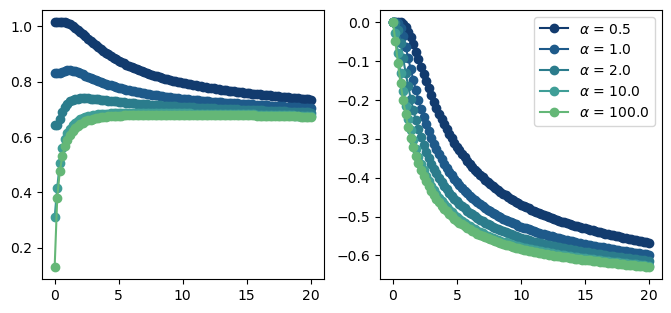

In [15]:
colors = [
    "#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
]
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)
for i, alpha in enumerate(alphas):
    axes[0].plot(lens[alpha]/alpha, non_queries[alpha]+tails[alpha], marker='o', label=rf'$\alpha$ = {alpha}', color=colors[i])
    axes[1].plot(lens[alpha]/alpha, tails[alpha], marker='o', label=rf'$\alpha$ = {alpha}', color=colors[i])
plt.legend()
# plt.xscale('log')

Text(0, 0.5, 'Query-induced error')

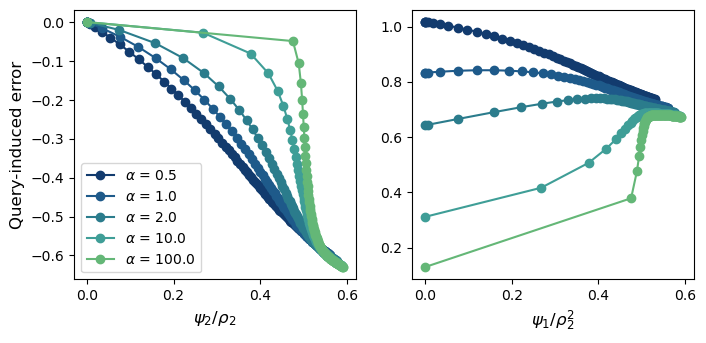

In [17]:
colors = [
    "#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
]
loc = 5
mult = 3
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)
for i, alpha in enumerate(alphas):
    axes[0].plot(psi2[alpha]/rho2[alpha], tails[alpha], marker='o',label=rf'$\alpha$ = {alpha}', color=colors[i])
    axes[1].plot(psi2[alpha]/rho2[alpha], non_queries[alpha]+tails[alpha], marker='o',label=rf'$\alpha$ = {alpha}', color=colors[i])
    # axes[0].scatter((psi2[alpha]/rho2[alpha])[mult*loc], tails[alpha][mult*loc], marker='o', color='red', zorder=10)
    # axes[1].scatter((psi1[alpha]/(rho2[alpha]**2))[mult*loc], tails[alpha][mult*loc], marker='o', color='red', zorder=10)

axes[0].legend()
axes[0].set_xlabel(r'$\psi_2/\rho_2$',fontsize=12)
axes[1].set_xlabel(r'$\psi_1/\rho_2^2$',fontsize=12)
axes[0].set_ylabel('Query-induced error',fontsize=12)
# plt.savefig(rf'query-error-tau{tau}-kappa{kappa}.pdf')

In [60]:
d = 128
alphas = np.logspace(np.log10(0.5), np.log10(100), 20)
mults = [0.5, 1, 2, 3, 10]
kappa = 0.5
tau = 4.0
rho = 0.01


lens = {}
non_queries = {}
tails = {}
k0 = {}
k1 = {}
k2 = {}
psi1 = {}
psi2 = {}
rho2 = {}

for mult in mults:
    lens[mult] = mult*alphas
    non_queries_temp = np.zeros(len(lens[mult]))
    tails_temp = np.zeros(len(lens[mult]))
    k0s_temp = np.zeros(len(lens[mult]))
    k1s_temp = np.zeros(len(lens[mult]))
    k2s_temp = np.zeros(len(lens[mult]))
    for i in range(len(alphas)):
        xi = lens[mult][i]
        l = int(alphas[i]*d)
        K = kernel_exp(l, xi)
        k0s_temp[i], k1s_temp[i], _, k2s_temp[i] = icl_kernel_stats(K)
        non_queries_temp[i], tails_temp[i] = icl_correlated_REARRANGED(tau, alpha, kappa, rho, K)
    non_queries[mult] = non_queries_temp; tails[mult] = tails_temp; k0[mult] = k0s_temp; k1[mult] = k1s_temp; k2[mult] = k2s_temp
    rho2[mult] = (k2[mult]+rho)/alphas
    psi1[mult] = (1/alphas**2)*(k1[mult]+rho*k0[mult])
    psi2[mult] = k0[mult]/alphas

/tmp/ipykernel_3493934/2427534497.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'Query-induced error')

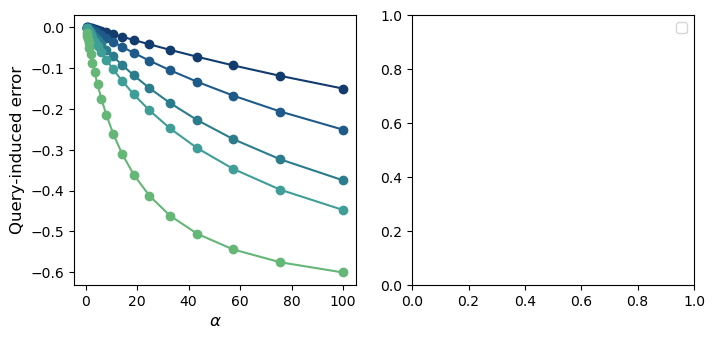

In [61]:
colors = [
    "#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
]
loc = 5
mult = 3
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)
for i, mult in enumerate(mults):
    axes[0].plot(alphas, tails[mult], marker='o',label=rf'$\xi$ = {mult}$\times \alpha$', color=colors[i])
    # axes[1].plot(alphas, tails[alpha], marker='o',label=rf'$\alpha$ = {alpha}', color=colors[i])
    # axes[0].scatter((psi2[alpha]/rho2[alpha])[mult*loc], tails[alpha][mult*loc], marker='o', color='red', zorder=10)
    # axes[1].scatter((psi1[alpha]/(rho2[alpha]**2))[mult*loc], tails[alpha][mult*loc], marker='o', color='red', zorder=10)

plt.legend()
axes[0].set_xlabel(r'$\alpha$',fontsize=12)
# axes[1].set_xlabel(r'$\psi_1/\rho_2^2$',fontsize=12)
axes[0].set_ylabel('Query-induced error',fontsize=12)
# plt.savefig(rf'query-error-tau{tau}-kappa{kappa}.pdf')

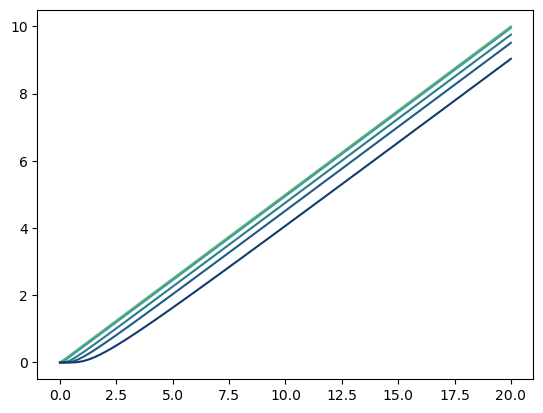

In [41]:
for i, alpha in enumerate(alphas):
    plt.plot(lens[alpha]/alpha, k0[alpha]/alpha, color=colors[i], zorder=6-i)

In [ ]:
deez = [16, 32, 64, 128]
alphas = np.logspace(np.log10(0.1), np.log10(100), 10)
xi = 10

results = {}

for d in deez:
    k0_vals = []
    k1_vals = []
    k2_vals = []
    l_vals = []

    for alpha in alphas:
        l = int(alpha * d)
        K = kernel_exp(l, xi)
        k0, k1, _, k2 = icl_kernel_stats(K)

        l_vals.append(l)
        k0_vals.append(k0)
        k1_vals.append(k1)
        k2_vals.append(k2)

    results[d] = {
        "alpha": np.array(alphas),
        "l": np.array(l_vals),
        "k0": np.array(k0_vals),
        "k1": np.array(k1_vals),
        "k2": np.array(k2_vals),
    }

In [ ]:
np.int64(128*alphas)

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=True)

quantities = ["k0", "k1", "k2"]

for ax, q in zip(axes, quantities):
    for d in deez:
        ax.plot(results[d]["alpha"], results[d][q], marker="o", label=f"d={d}")
    
    ax.set_xscale("log")
    ax.set_ylabel(q)
    ax.legend()
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("alpha")

plt.tight_layout()
plt.show()

In [ ]:
d = 32

alphas = np.logspace(np.log10(0.1),np.log10(100),25)
tau = 1000
kappa = 1000
rho = 0.01

vals = []
i = 0
for alpha in alphas:
    print(i)
    l = int(alpha*d)
    K = kernel_exp(l, 10)
    vals.append(icl_correlated(tau, alpha, kappa, rho, K))
    i += 1
    

ridges = [rho*(1 + (1/alpha)*M_kappa(rho/alpha, alpha, 1)) for alpha in alphas]

In [ ]:
plt.plot(alphas, vals)
plt.plot(alphas, ridges)
plt.xscale('log')

## **Sweeps over correlation length**

In [17]:
tau = 4.0
alpha = 10.0
kappa = 1.0
rho = 0.01
numavg = 20
lambdareg = 1e-8

runs_mean = {}
runs_stds = {}
lens = {}
alphas = {}
for d in [128]:
    #alphas[d] = [1/d, 2/d, 5/d, 1, 10] 
    lens[d] = np.linspace(0, 10*alpha, 11) #jnp.array([0,1,alpha,10*alpha, d, alpha*d,5*alpha*d,20*alpha*d]).astype(jnp.float64)
    runs_mean[d], runs_stds[d], =  run_sweep_over_corr_lens(lens[d], seed=0, d=d, tau=tau, alpha=alpha, kappa=kappa,
            rho=rho, numavg=numavg, lambdareg=lambdareg,
            cg_tol=1e-8, cg_maxiter=2000, from_data=True)
    # run_sweep_over_alphas(alphas[d], lens[d], seed=0, d=d, tau=tau, kappa=kappa,
    #           rho=rho, numavg=numavg, lambdareg=lambdareg,
    #           cg_tol=1e-4, cg_maxiter=200, from_data=True)


In [23]:
d = 128
rho = 0.01
# matched=[]
newalphas = {}
lens = {}
alphas = [0.5, 1, 2, 5, 10, 100]
for alpha in alphas:
    lens[alpha] = np.linspace(0, 5*alpha, 21)
    temp = []
    for xi in lens[alpha]:
        K = kernel_exp(int(alpha*d), xi)
        _,_,_,tk2 = icl_kernel_stats(K)
        new_alpha = tk2 #alpha*(rho + tk2)/(1+rho)
        temp.append(new_alpha)
    newalphas[alpha] = temp

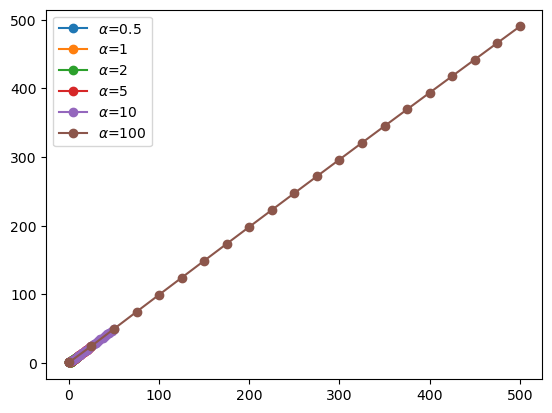

In [25]:
for alpha in alphas:
    plt.plot(lens[alpha], np.array(newalphas[alpha]), marker='o', label=rf'$\alpha$={alpha}')
plt.legend()

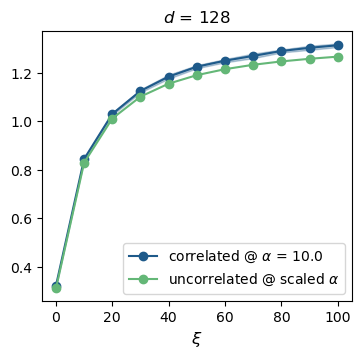

In [19]:
colors = [
    #"#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
]
plt.figure(figsize=(4, 3.5))
plt.plot(lens[d], runs_mean[d][:,0], marker='o', label=fr'correlated @ $\alpha$ = {alpha}',color=colors[0])
plt.fill_between(lens[d], np.array(runs_mean[d][:,0]) - np.array(runs_stds[d][:,0]), np.array(runs_mean[d][:,0]) + np.array(runs_stds[d][:,0]), alpha=0.3, color=colors[0]) 
plt.plot(lens[d], matched, marker='o', label=fr'uncorrelated @ scaled $\alpha$', color=colors[3])
plt.xlabel(r'$\xi$',fontsize=12)
plt.title(rf'$d$ = {d}')
plt.legend()
plt.savefig(rf'matched_alpha{alpha}.pdf')

In [ ]:
vals = {}
for d in [16,32,64,128]:
    alphas[d] = [1/d, 2/d, 5/d, 1, 10] 
    vals[d] = [icl_uncorrelated(tau, alpha, alpha, kappa, rho, 1, 1) for alpha in alphas[d]]

In [ ]:
colors = [
    "#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
    # 'orange',
    # 'orange',
    # 'brown',
    # 'red'
]
ds = [16,32,64,128]
num_corrs = len(lens[ds[0]])
labels = ['1', '2', '5', r'$d$', r'$10d$']

fig, ax = plt.subplots()

for i in range(num_corrs):
    means_current = jnp.array([runs_mean[d][i] for d in ds])
    stds_current = jnp.array([runs_stds[d][i] for d in ds])
    theory_current = jnp.array([vals[d][i] for d in ds])
    ax.plot(ds, means_current-theory_current, marker='o', color=colors[i], label=rf'$\ell$ = {labels[i]}')
    ax.fill_between(ds, means_current-stds_current-theory_current, means_current+stds_current-theory_current, alpha=0.2, color=colors[i])
    # ax.scatter(ds, , marker='s', color=colors[i])


plt.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(ds)      
ax.set_xticklabels(ds)
ax.set_xlabel(r'$d$', fontsize=15)
ax.set_ylabel('ICL Simulation - ICL Theory', fontsize=15)
ax.minorticks_off()        # removes minor ticks

In [ ]:
colors = [
    "#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    # "#64B777",  # soft green
    'orange',
    'orange',
    'brown',
    'red'
]
ds = [16,32,64,128]
num_corrs = len(lens[ds[0]])
labels = ['0', '1', r'$\alpha$',  r'$10\alpha$', r'$d$', r'$\ell$', r'$5\ell$', r'$20\ell$']

fig, ax = plt.subplots()

vals = [0,1,2,5,6,7]
for i in vals:
    means_current = jnp.array([runs_mean[d][i] for d in ds])
    stds_current = jnp.array([runs_stds[d][i] for d in ds])
    ax.plot(ds, means_current, marker='o', color=colors[i], label=rf'$\xi$ = {labels[i]}')
    ax.fill_between(ds, means_current-stds_current, means_current+stds_current, alpha=0.2, color=colors[i])

plt.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xticks(ds)      
ax.set_xticklabels(ds)
ax.set_xlabel(r'$d$', fontsize=15)
ax.set_ylabel('ICL Simulation Error', fontsize=15)
ax.minorticks_off()        # removes minor ticks

In [ ]:
tau = 4.0
alpha = 5.5
kappa = 1.0
rho = 0.01
numavg = 20
lambdareg = 1e-8

lens = jnp.linspace(0.0, 5 * alpha, 26).astype(jnp.float64)

runs_mean = {}
runs_stds = {}
for d in [16,32,64,128]:
    runs_mean[d], runs_stds[d], = run_sweep_over_corr_lens(lens, seed=0, d=d, tau=tau, alpha=alpha, kappa=kappa,
            rho=rho, numavg=numavg, lambdareg=lambdareg,
            cg_tol=1e-8, cg_maxiter=2000)

In [ ]:
colors = [
    "#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
]

for i, d in enumerate([16,32,64,128]):
    plt.plot(lens, runs_mean[d]-np.array(theory), marker='o', label=rf'$d$ = {d}', color=colors[i])
    plt.fill_between(lens, runs_mean[d]-np.array(theory)-runs_stds[d], runs_mean[d]-np.array(theory)+runs_stds[d], alpha=0.4, color=colors[i])

# theory = theory_sweep_over_corr_lens(lens, 128, tau, alpha, kappa, rho)
# plt.plot(lens, theory, marker='s', color='red', label='theory')

plt.axvline(alpha, linestyle=':', color='black', label=r'$\xi = \alpha$')
plt.legend()
# plt.yscale('log')
plt.xlabel(r'$\xi$', fontsize=15)
plt.ylabel('Relative error between theory', fontsize=15)
plt.title(rf'$\tau$ = {tau}, $\alpha$ = {alpha}, $\kappa$ = {kappa}')
plt.savefig(f'changingcorr_t{tau}_a{alpha}_k{kappa}_ALLd_RELATIVE.png')

## **Sweeps over context length**

In [ ]:
import numpy as np

def n_eff_ar1(N, xi):
    if N <= 0:
        raise ValueError("N must be a positive integer.")
    if xi <= 0:
        raise ValueError("xi must be positive.")
    if N == 1:
        return 1.0

    k = np.arange(1, N)
    rho = np.exp(-k / xi)
    denom = 1.0 + 2.0 * np.sum((1.0 - k / N) * rho)
    return N / denom

In [ ]:
eff

In [ ]:
tau = 4.0
kappa = 1.0
rho = 0.01
numavg = 20
lambdareg = 1e-8
alphas = np.logspace(np.log10(0.1), np.log10(100), 10)
lens = alphas
d = 128

eff = []

for i in range(len(alphas)):
    eff.append(max(n_eff_ar1(int(alphas[i]*d), lens[i])/d, 1/d))

theory_true = theory_sweep_over_alphas(alphas, lens, d=d, tau=tau, kappa=kappa, rho=rho)
theory_guess = theory_sweep_over_alphas(eff, jnp.zeros(len(alphas)), d=d, tau=tau, kappa=kappa, rho=rho)
theory_uncorrelated = theory_sweep_over_alphas(alphas, jnp.zeros(len(alphas)), d=d, tau=tau, kappa=kappa, rho=rho)

In [ ]:
plt.plot(alphas, theory_true, marker='o', label='correlated samples')
plt.plot(alphas, theory_guess, marker='o', label='uncorrelated at reduced length')
plt.plot(alphas, theory_uncorrelated, marker='o', label='uncorrelated samples')
plt.xscale('log')
plt.xlabel(r'$\alpha$ = Context length / $d$')
plt.ylabel('ICL error')
plt.legend()

In [ ]:
np.logspace(np.log10(0.1), np.log10(100), 10)

In [51]:
tau = 0.5
alpha = 1.0
rho = 0.01
numavg = 20
lambdareg = 1e-8

# alphas = np.logspace(np.log10(0.1), np.log10(100), 10) #jnp.linspace(0.5, 5.5, 11).astype(jnp.float64)
#kappas = np.logspace(np.log10(0.1), np.log10(100), 10)
# kappa = 0.5
#taus = np.linspace(0.1, 2.1, 11)

# betas = np.logspace(np.log10(0.1), np.log10(100), 10)
# alphas = alpha*np.ones(len(betas))
beta = 50

runs_mean = {}
runs_std = {}
theory = {}

for d in [16, 128]:
    runs_mean[d], runs_std[d] =  run_sweep_over_corr_lens(np.int64(betas*d*alpha), seed=0, d=d, tau=tau, alpha=alpha, kappa=kappa,
              rho=rho, numavg=numavg, lambdareg=lambdareg,
              cg_tol=1e-8, cg_maxiter=2000)
    
    # run_sweep_over_kappas(kappas, seed=0, d=d, tau=tau, alpha=alpha,
    #           rho=0.01, corr_len=int(alpha*d*beta), numavg=numavg, lambdareg=lambdareg,
    #           cg_tol=1e-4, cg_maxiter=2000)


    
    # run_sweep_over_alphas(alpha*np.ones(len(betas)), np.int64(betas*d*alpha), seed=0, d=d, tau=tau, kappa=kappa,
    #         rho=rho, numavg=numavg, lambdareg=lambdareg,
    #         cg_tol=1e-8, cg_maxiter=2000
    # )


    # = run_sweep_over_taus(taus, seed=0, d=d, alpha=alpha, kappa=kappa,
    #           rho=0.01, corr_len=int(alpha*d*50), numavg=numavg, lambdareg=lambdareg,
    #           cg_tol=1e-4, cg_maxiter=200)

    #theory[d] = theory_sweep_over_alphas(alpha*np.ones(len(betas)), np.int64(betas*d*50), d=d, tau=tau, kappa=kappa, rho=rho)
    print(f'd = {d} done')

d = 16 done
d = 128 done


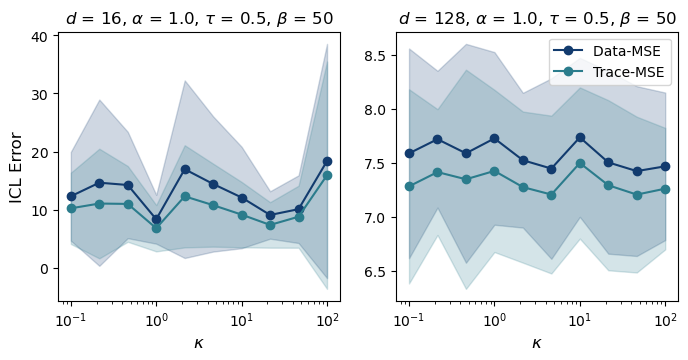

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5), sharey=False)
deez = [16, 128]

colors = [
    "#123B6E",  # rich blue (added)
    "#2B7C8C",  # teal
    "#64B777",  # soft green
]

for i, d in enumerate(deez): 
    axes[i].plot(kappas, runs_mean[d][:,0], marker='o', label='Data-MSE ', color=colors[0])
    axes[i].fill_between(kappas, np.array(runs_mean[d][:,0])-np.array(runs_std[d][:,0]), np.array(runs_mean[d][:,0])+np.array(runs_std[d][:,0]), alpha=0.2, color=colors[0])
    axes[i].plot(kappas, runs_mean[d][:,1], marker='o', label='Trace-MSE', color=colors[1])
    axes[i].fill_between(kappas, np.array(runs_mean[d][:,1])-np.array(runs_std[d][:,1]), np.array(runs_mean[d][:,1])+np.array(runs_std[d][:,1]), alpha=0.2, color=colors[1])
    #axes[i].plot(kappas, theory[d], marker='o', label='Theory', color=colors[2])
    axes[i].set_xscale('log')
    axes[i].set_title(rf'$d$ = {d}, $\alpha$ = {alpha}, $\tau$ = {tau}, $\beta$ = {beta}')
    axes[i].set_xlabel(r'$\kappa$', fontsize=12)
    # axes[i].axvline(10, linestyle=':', color='red', label='corr. len')
axes[-1].legend()
axes[0].set_ylabel('ICL Error', fontsize=12)

plt.savefig(f'NOW AGAINST KAPPA AGAIN cgsolve 2000.pdf',bbox_inches='tight')

In [34]:
betas[8]

np.float64(46.41588833612777)

In [42]:
runs_mean[128][8,0]

Array(10.99822515, dtype=float64)

In [60]:
d = 128
tau = 0.5; n = int(tau*d*d)
kappa = 0.5; k_tasks = int(kappa*d)
beta = betas[8]; corr_len = int(alpha*d*beta)
alpha = 1.0; l = int(alpha*d)
C = np.eye(d)
C_test = C

print(f"tau is {tau}")
print(f"kappa is {kappa}")
print(f"beta is {beta}")
print(f"alpha is {alpha}")
val = one_replicate(random.PRNGKey(0), n, d, l, rho, C, C_test, corr_len, lambdareg, alpha, k_tasks,
                  1e-4, 200, False)
# avg_over_replicates(
#     random.PRNGKey(0), numavg, int(tau*d*d), d, int(alpha*d), rho, np.eye(d), np.eye(d), int(alpha*d*beta),
#     lambdareg, alpha, int(kappa*d), False, cg_tol=1e-4, cg_maxiter=2000)

tau is 0.5
kappa is 0.5
beta is 46.41588833612777
alpha is 1.0
residual =  0.00054003895961486


In [59]:
val

(Array(4.11120803, dtype=float64), Array(6.88197803, dtype=float64))

In [ ]:
colors = [
    "#123B6E",  # deep navy
    "#1E5A8A",  # rich blue (added)
    "#2B7C8C",  # teal
    "#3F9E97",  # sea-green (added)
    "#64B777",  # soft green
]

for i, d in enumerate([16,32,64,128]):
    plt.plot(alphas, jnp.array(theory)-runs_mean[d], marker='o', label=rf'$d$ = {d}', color=colors[i])
    plt.fill_between(alphas, jnp.array(theory)-runs_mean[d]-runs_std[d], jnp.array(theory)-runs_mean[d]+runs_std[d], alpha=0.4, color=colors[i])

# theory = theory_sweep_over_alphas(alphas, lens, d=128, tau=0.5, kappa=1.0, rho=0.01)
# plt.plot(alphas, theory, marker='s', color='red', label='theory')

plt.legend() 
# plt.yscale('log')
plt.xlabel(r'$\alpha$ = $10\xi/d$', fontsize=15)
plt.ylabel('Relative error between theory', fontsize=15)
plt.title(rf'$\tau$ = {tau}, $\kappa$ = {kappa}')
plt.savefig(f'xi_ell_t{tau}_k{kappa}_ALLd.png')

In [ ]:
plt.plot(lens, samples_at_alpha_128, color='blue', marker='o', label='data 128')
plt.plot(lens, t128, linestyle=':', marker='s', color='green', label='theory 128')
plt.plot(lens, samples_at_alpha_32, color='orange', marker='o', label='data 32')
plt.plot(lens, t32, linestyle=':', marker='s', color='red', label='theory 32')
plt.legend()

## **Extra**

In [ ]:
'''
Difference between directly building H matrix and solving for gamma
vs 
iterative solver without directly building H
'''

def build_H_from_suffstats(x_l, y_sum_x, y_sum_y, d, l):
    """
    Reconstructs H_Z exactly from sufficient stats, matching your original construct_H_Z.
    Returns H: (n, d, d+1)
    """
    right = jnp.concatenate([(d / l) * y_sum_x, (1.0 / l) * y_sum_y[:, None]], axis=1)  # (n, d+1)
    H = x_l[:, :, None] * right[:, None, :]  # (n, d, d+1)
    return H

def gamma_dense_from_H(H, y_last, n, d, lambdareg):
    """
    Exactly your original:
      Gamma = inv((n/d)*lambda I + H^T H) H^T y
    but using jnp.linalg.solve (dense).
    """
    Hvec = H.reshape(n, -1)  # (n, p)
    p = Hvec.shape[1]
    reg = (n / d) * lambdareg
    A = (Hvec.T @ Hvec) + reg * jnp.eye(p, dtype=Hvec.dtype)   # (p, p)
    b = Hvec.T @ y_last                                        # (p,)
    gamma = jnp.linalg.solve(A, b)
    return gamma.reshape(d, d + 1)

def gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg, cg_tol=1e-10, cg_maxiter=5000):
    """
    Same normal equations solve, but matrix-free CG on p=d(d+1).
    """
    p = d * (d + 1)
    reg = (n / d) * lambdareg

    def matvec(v_flat):
        v_mat = v_flat.reshape(d, d + 1)
        hv = Hv(v_mat, x_l, y_sum_x, y_sum_y, d, l)
        ht_h_v = HTu(hv, x_l, y_sum_x, y_sum_y, d, l)
        return (reg * v_mat + ht_h_v).reshape(p)

    b_mat = HTu(y_last, x_l, y_sum_x, y_sum_y, d, l)
    b = b_mat.reshape(p)

    gamma, _ = cg(matvec, b, tol=cg_tol, maxiter=cg_maxiter)

    # report residual
    r = b - matvec(gamma)
    rel_res = jnp.linalg.norm(r) / (jnp.linalg.norm(b) + 1e-30)

    return gamma.reshape(d, d + 1), rel_res

def debug_compare_one_point(key, *, d=32, tau=0.5, alpha=1.0, kappa=1.0, rho=0.01,
                            corr_len=0.0, lambdareg=1e-4, cg_tol=1e-10, cg_maxiter=5000):
    """
    Runs one replicate at a single corr_len and compares:
      - Gamma from dense solve (explicit H)
      - Gamma from CG operator
      - resulting ICL error
    """
    l = int(alpha * d)
    n = int(tau * d * d)
    k_tasks = int(kappa * d)

    # use float64 if enabled
    dtype = jnp.float64 if jax.config.jax_enable_x64 else jnp.float32
    C = jnp.eye(d, dtype=dtype)
    C_test = C

    K = kernel_exp(l, jnp.asarray(corr_len, dtype=dtype))
    k0, k1, tk, tk2 = icl_kernel_stats(K)

    x_l, y_sum_x, y_sum_y, y_last = simulate_sufficient_stats_finite_k(
        key, n=n, d=d, l=l, rho=rho, C=C, corr_len=corr_len, k_tasks=k_tasks
    )

    # Dense
    H = build_H_from_suffstats(x_l, y_sum_x, y_sum_y, d, l)
    Gamma_dense = gamma_dense_from_H(H, y_last, n, d, lambdareg)

    err_dense = ICL_trace_from_Gamma(Gamma_dense, d, l, jnp.asarray(rho, dtype), C_test,
                                     k0, k1, tk, tk2, jnp.asarray(alpha, dtype))

    # CG operator
    Gamma_cg, rel_res = gamma_cg_operator(x_l, y_sum_x, y_sum_y, y_last, n, d, l, lambdareg,
                                          cg_tol=cg_tol, cg_maxiter=cg_maxiter)

    err_cg = ICL_trace_from_Gamma(Gamma_cg, d, l, jnp.asarray(rho, dtype), C_test,
                                  k0, k1, tk, tk2, jnp.asarray(alpha, dtype))

    # Compare Gammas
    diff = jnp.linalg.norm(Gamma_dense - Gamma_cg) / (jnp.linalg.norm(Gamma_dense) + 1e-30)

    return {
        "n": n, "p": d*(d+1),
        "err_dense": err_dense,
        "err_cg": err_cg,
        "gamma_rel_diff": diff,
        "cg_rel_res": rel_res,
    }